In [8]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from src.geometry.dataset import load_dataset
from src.detector import HoughCirclesDetector

from src.plotting import draw_circle
from src.plotting import draw_image

In [7]:
dataset = load_dataset("data/stamps/annotation.json")
example = dataset[0]

detector = HoughCirclesDetector(
    dp=1.2, param1=50, param2=80, minDistRate=0.1, minRadius=50, maxRadius=140,
    blur_params={"ksize": (9, 9), "sigmaX": 3.0}
)


circles = detector.detect(example.image)
circles

array([[286.2     , 906.60004 ,  75.92    ],
       [551.4     , 724.2     ,  86.479996]], dtype=float32)

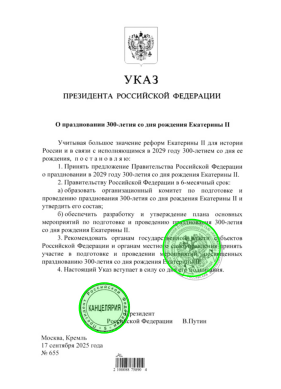

In [12]:
edgecolor = (0, 1, 0, 1.0)
facecolor = (0, 1, 0, 0.2)

ax = plt.subplot(1, 1, 1)

draw_image(ax, example.image)


for (x, y, r) in circles:
    draw_circle(ax, x, y, r, facecolor=facecolor, edgecolor=edgecolor)

plt.show()

### **Пример эксперимента**

In [22]:
from copy import deepcopy

from src.geometry.metrics import mean_intersection_over_union
from src.geometry.matching import matching_precision
from src.geometry.matching import matching_recall

from src.geometry.matching import MatchingResult
from src.geometry.matching import match

from src.geometry.utils import opencv_hough_circles_to_ellipses

In [31]:
def extend_matching_result(extended, extension):
    extended = deepcopy(extended)

    extended.true_matched.extend(extension.true_matched)
    extended.pred_matched.extend(extension.pred_matched)
    extended.true_unmatched.extend(extension.true_unmatched)
    extended.pred_unmatched.extend(extension.pred_unmatched)

    return extended


def compute_f1_score(precision, recall):
    return 2 * precision * recall / (precision + recall)


def compute_metrics(matching):
    iou = mean_intersection_over_union(
        matching.true_matched, matching.pred_matched
    )
    precision = matching_precision(matching)
    recall = matching_recall(matching)
    f1_score = compute_f1_score(precision, recall)
    return {
        "IoU": iou, "precision": precision, "recall": recall, "f1": f1_score
    }


def run_experiment(dataset, params):
    detector = HoughCirclesDetector(**params)
    all_matching = MatchingResult([], [], [], [])

    for image_a in dataset:
        stamps = image_a.ellipses
        circles = detector.detect(image_a.image)
        circles = opencv_hough_circles_to_ellipses(image_a.image, circles)
        
        image_matching = match(stamps, circles, threshold=0.5)
        all_matching = extend_matching_result(all_matching, image_matching)
    
    metrics = compute_metrics(all_matching)
    return metrics
        

In [32]:
run_experiment(
    dataset=dataset,
    params={
        "dp": 1.2, "param1": 50, "param2": 80,
        "minDistRate": 0.1, "minRadius": 50, "maxRadius": 140,
        "blur_params": {"ksize": (9, 9), "sigmaX": 3.0}
    }
)

{'IoU': np.float64(0.8996092533761679),
 'precision': 0.9576719576719577,
 'recall': 0.9476439790575916,
 'f1': 0.9526315789473683}